<a href="https://colab.research.google.com/github/aman-verma02/Convolutional-Neural-Network/blob/main/Dogs_cats_Classification_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
salader_dogsvscats_path = kagglehub.dataset_download('salader/dogsvscats')

print('Data source import complete.')


Using Colab cache for faster access to the 'dogsvscats' dataset.
Data source import complete.


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import os

print(f"Listing files in: {salader_dogsvscats_path}")
for dirname, _, filenames in os.walk(salader_dogsvscats_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [11]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense , Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout

In [5]:
import os

# generators
train_ds = keras.utils.image_dataset_from_directory(
    directory = os.path.join(salader_dogsvscats_path, 'train'), # Adjusted directory to point to 'train' subfolder
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256,256)
)
validation_ds = keras.utils.image_dataset_from_directory(
    directory = os.path.join(salader_dogsvscats_path, 'test'), # Adjusted directory to point to 'test' subfolder (common for validation)
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256,256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [6]:
## Normalizing the data
def process (image , label):
  image = tf.cast(image/255. , tf.float32)
  return image , label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [14]:
## CNN model

model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [17]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [18]:
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 95ms/step - accuracy: 0.6110 - loss: 1.2102 - val_accuracy: 0.6854 - val_loss: 0.5858
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 95ms/step - accuracy: 0.7229 - loss: 0.5447 - val_accuracy: 0.7126 - val_loss: 0.5651
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.7847 - loss: 0.4613 - val_accuracy: 0.7248 - val_loss: 0.5246
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 94ms/step - accuracy: 0.8174 - loss: 0.4029 - val_accuracy: 0.7992 - val_loss: 0.4822
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.8489 - loss: 0.3421 - val_accuracy: 0.7870 - val_loss: 0.4468
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 98ms/step - accuracy: 0.8874 - loss: 0.2712 - val_accuracy: 0.8106 - val_loss: 0.4309
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 97ms/step - accuracy: 0.9234 - loss: 0.1907 - val_accuracy: 0.8032 - val_loss: 0.4891
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 92ms/step - accuracy: 0.9534 - loss: 0.1233 - 

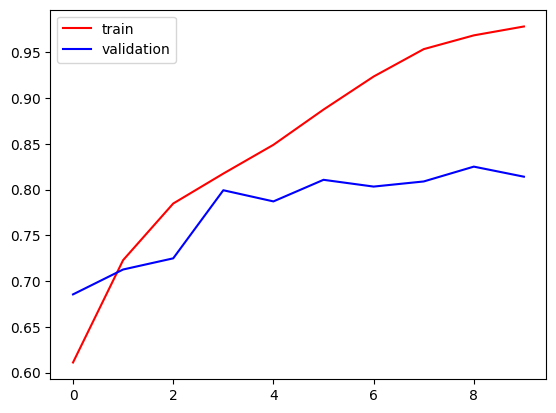

In [19]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.legend()
plt.show()

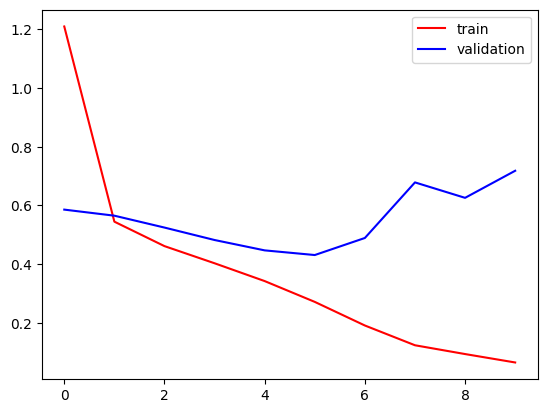

In [20]:
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
https://imgs.search.brave.com/5R9eoFuWfMY9tQNaEK-TqqzM-_RVwTYK6acxE_zdLnE/rs:fit:860:0:0:0/g:ce/aHR0cHM6Ly9tZWRp/YS5pc3RvY2twaG90/by5jb20vaWQvMjIz/MDkxNzE2NS9waG90/by9jdXRlLWJpZXdl/ci15b3Jrc2hpcmUt/dGVycmllci1kb2ct/b3V0ZG9vcnMtaW4t/c3VtbWVyLndlYnA_/YT0xJmI9MSZzPTYx/Mng2MTImdz0wJms9/MjAmYz1RT3p6ZkVs/XzIzb1JpeVppT29v/UGVpdmt3RUt6V3ZC/ZGdRWUxINnRpdmM0/PQ

In [26]:
# Store the image URL in a variable
image_url = 'https://imgs.search.brave.com/zI76RAtS2xPO9FMTHQxWIg34o2_KBbdnua5L2yQvyow/rs:fit:860:0:0:0/g:ce/aHR0cHM6Ly9tZWRp/YS5nZXR0eWltYWdl/cy5jb20vaWQvOTMy/MTA3MzYyL3Bob3Rv/L2JpZy1leWVkLW5h/dWdodHktb2Jlc2Ut/Y2F0LWxvb2tpbmct/YXQtdGhlLXRhcmdl/dC1icml0aXNoLXNv/cnQtaGFpci1jYXQu/anBnP3M9NjEyeDYx/MiZ3PTAmaz0yMCZj/PS1YTUo4ckRvd0lW/SGlWSDNublpUb2Vs/T3RkajB1ZncxcTBP/RmNTcWdWR289'

Next, we'll download the image, preprocess it to the correct size and format for your model, and then make a prediction.

In [27]:
import requests
from PIL import Image
import numpy as np
from io import BytesIO

# Function to load and preprocess an image from a URL
def load_and_preprocess_image_from_url(image_url, target_size=(256, 256)):
    response = requests.get(image_url)
    img = Image.open(BytesIO(response.content))
    img = img.resize(target_size)
    img_array = np.array(img)
    # Add batch dimension and normalize
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0  # Normalize to [0, 1] as per your model preprocessing
    return img_array

# Load and preprocess the image
processed_image = load_and_preprocess_image_from_url(image_url)

# Make a prediction
prediction = model.predict(processed_image)

# Interpret the prediction
if prediction[0][0] > 0.5:
    print(f"Prediction: Dog (Confidence: {prediction[0][0]:.2f})")
else:
    print(f"Prediction: Cat (Confidence: {1 - prediction[0][0]:.2f})")

# You can also display the image if you like
# import matplotlib.pyplot as plt
# plt.imshow(processed_image[0])
# plt.axis('off')
# plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Prediction: Cat (Confidence: 0.92)
